# LogHAR Model on the MHAR 5-min Feature Set

**Purpose:** The purpose of this notebook is to compute the out-of-sample forecast performance 
of the logarithmic Heterogeneous Autoregressive (logHAR) model of \citet{Corsi2009} on the 
$\mathcal{M}_{\mathrm{HAR}}$ 5-min feature set for the EURO STOXX 50 index over the 
period 1999–2020, following the methodology of \citet{Christensen2023}.

The logHAR model is defined as:

$$\log(RV_{t+1}) = \beta_0 + \beta_d \log(RV_t) + \beta_w \log(\overline{RV}_t^{(w)}) + 
\beta_m \log(\overline{RV}_t^{(m)}) + \varepsilon_{t+1}$$

where the predictors are the logarithms of realized variance measures:

- $\log(RV_t)$ (log RVD) — daily realized variance  
- $\log(\overline{RV}_t^{(w)}) = \log\left(\frac{1}{5}\sum_{i=0}^{4} RV_{t-i}\right)$ (log RVW) —  5-day rolling average of RV
- $\log(\overline{RV}_t^{(m)}) = \log\left(\frac{1}{22}\sum_{i=0}^{21} RV_{t-i}\right)$ (log RVM) —  22-day rolling average of RV

To obtain forecasts in levels, predictions from the logHAR model are transformed using a bias correction of the form:

$$\widehat{RV}_{t+1} = \exp\left(\widehat{\log(RV_{t+1})} + \frac{1}{2}\widehat{\sigma}^2 \right)$$

where $\widehat{\sigma}^2$ denotes the estimated variance of the regression residuals, ensuring consistency under log-normality.

The model is estimated via Ordinary Least Squares (OLS) using a rolling window 
of fixed length equal to the combined training and validation set (4,389 
observations), rolling forward one day at a time across the test period of 
1,099 observations (2016-04-20 to 2020-08-05).

## 1. Loading Data
Loading in data from the MALL_5min.csv file

In [57]:
import pandas as pd
import numpy as np

# Load MALL dataset
file_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/MALL_5min.csv"
MALL = pd.read_csv(file_path, index_col='Date', parse_dates=True)

print(f"Shape: {MALL.shape}")
print(f"Date range: {MALL.index[0].date()} to {MALL.index[-1].date()}")
print(f"NaN values: {MALL.isna().sum().sum()}")
print("\nLogHAR columns available:")
print(MALL[["logRVD", "logRVW", "logRVM", "logRV_target"]].head())

Shape: (5489, 31)
Date range: 1999-01-05 to 2020-08-06
NaN values: 0

LogHAR columns available:
              logRVD    logRVW    logRVM  logRV_target
Date                                                  
1999-01-05 -9.153100 -9.328531 -8.866447     -9.966398
1999-01-06 -9.966398 -9.316927 -8.935760     -8.347779
1999-01-07 -8.347779 -9.004761 -8.938374     -8.689606
1999-01-08 -8.689606 -8.832472 -9.082830     -8.175339
1999-01-11 -8.175339 -8.692020 -9.056351     -8.565468


## 2. Data Split
### 2.1 Train / Validation / Test Split (70 / 10 / 20)

Following Christensen et al. (2023), we split the sample into a training set (70%), 
validation set (10%), and test set (20%). The test set is reserved exclusively for 
out-of-sample evaluation and no estimation or tuning is conducted on it.

In [61]:
# Train / Validation / Test split (70 / 10 / 20)
n = len(MALL)
n_train = int(np.floor(0.70 * n))
n_val   = int(np.floor(0.10 * n))
n_test  = n - n_train - n_val

train_idx = MALL.index[:n_train]
val_idx   = MALL.index[n_train:n_train + n_val]
test_idx  = MALL.index[n_train + n_val:]

print(f"Total observations: {n}")
print(f"\nTrain:      {train_idx[0].date()} to {train_idx[-1].date()} ({n_train} obs, {n_train/n*100:.1f}%)")
print(f"Validation: {val_idx[0].date()} to {val_idx[-1].date()} ({n_val} obs, {n_val/n*100:.1f}%)")
print(f"Test:       {test_idx[0].date()} to {test_idx[-1].date()} ({n_test} obs, {n_test/n*100:.1f}%)")

Total observations: 5489

Train:      1999-01-05 to 2014-02-26 (3842 obs, 70.0%)
Validation: 2014-02-27 to 2016-04-20 (548 obs, 10.0%)
Test:       2016-04-21 to 2020-08-06 (1099 obs, 20.0%)


## 3. LogHAR Model

The LogHAR benchmark is estimated in log space as

$$\log(RV_{t+1}) = \beta_0 + \beta_d \log(RV_t) + \beta_w \log(\overline{RV}^{(w)}_t) + \beta_m \log(\overline{RV}^{(m)}_t) + \varepsilon_{t+1}$$

where the target is `logRV_target` and the predictors are the log-transformed MHAR variables available in `MALL.csv`. After forecasting in log space, realized values are exponentiated back to realized-variance levels, while forecasts are converted using the in-window residual-variance bias correction from Christensen et al. (2023) for evaluation and plotting.

### 3.2 Feature Set Construction
Extracting the dependent and independent variables relevant for the LogHAR model

In [66]:
# Define target and feature set for LogHAR on MHAR
y = MALL["logRV_target"]
X_MHAR = MALL[["logRVD", "logRVW", "logRVM"]]

print("Target variable: logRV_target")
print(f"Predictors: {X_MHAR.columns.tolist()}")
print(f"\nFirst few rows:")
print(pd.concat([y, X_MHAR], axis=1).head())

Target variable: logRV_target
Predictors: ['logRVD', 'logRVW', 'logRVM']

First few rows:
            logRV_target    logRVD    logRVW    logRVM
Date                                                  
1999-01-05     -9.966398 -9.153100 -9.328531 -8.866447
1999-01-06     -8.347779 -9.966398 -9.316927 -8.935760
1999-01-07     -8.689606 -8.347779 -9.004761 -8.938374
1999-01-08     -8.175339 -8.689606 -8.832472 -9.082830
1999-01-11     -8.565468 -8.175339 -8.692020 -9.056351


### 3.3 Rolling Window Estimation and Forecasting

In [69]:
from sklearn.linear_model import LinearRegression

# Rolling window length = train + validation
window = n_train + n_val

forecasts_LogHAR = []
forecasts_LogHAR_level = []
dates_test = []

for i in range(n_test):
    # Extract rolling window
    X_window = X_MHAR.iloc[i : i + window].values
    y_window = y.iloc[i : i + window].values

    # OLS estimation in log space
    model = LinearRegression()
    model.fit(X_window, y_window)

    # Bias correction in levels using residual variance from the rolling in-sample window
    residuals = y_window - model.predict(X_window)
    sigma2_hat = np.var(residuals, ddof=1)

    # One-step-ahead forecast using time t predictors
    X_forecast = X_MHAR.iloc[i + window].values.reshape(1, -1)
    forecast = model.predict(X_forecast)[0]
    forecast_level = np.exp(forecast + 0.5 * sigma2_hat)

    forecasts_LogHAR.append(forecast)
    forecasts_LogHAR_level.append(forecast_level)
    dates_test.append(MALL.index[i + window])

print(f"Forecasts generated: {len(forecasts_LogHAR)}")
print(f"Forecast period: {dates_test[0].date()} to {dates_test[-1].date()}")

Forecasts generated: 1099
Forecast period: 2016-04-21 to 2020-08-06


### 3.4 Out-of-Sample Performance Evaluation

Following Christensen et al. (2023), out-of-sample forecast accuracy is evaluated using 
the Mean Squared Error (MSE):

$$MSE = \frac{1}{T}\sum_{t \in \text{test}} (RV_{t+1} - \hat{f}(Z_t))^2$$

where $\hat{f}(Z_t)$ is the one-step-ahead forecast and $T$ is the number of test observations. For comparability with the HAR benchmark, LogHAR forecasts are first generated in log space and then converted back to realized-variance levels using the rolling in-window residual-variance bias correction before metrics are computed.


In [72]:
# Collect results in levels for direct comparison with HAR
results_LogHAR = pd.DataFrame({
    "RV_actual": np.exp(y.loc[dates_test].values),
    "RV_forecast": forecasts_LogHAR_level
}, index=dates_test)

# Compute out-of-sample MSE
mse_LogHAR = np.mean((results_LogHAR["RV_actual"] - results_LogHAR["RV_forecast"])**2)

print(f"Out-of-sample MSE (LogHAR): {mse_LogHAR:.6e}")
print(f"\nFirst few level forecasts vs actuals:")
print(results_LogHAR.head(10).to_string())

Out-of-sample MSE (LogHAR): 5.301097e-08

First few level forecasts vs actuals:
            RV_actual  RV_forecast
2016-04-21   0.000053     0.000098
2016-04-22   0.000081     0.000080
2016-04-25   0.000066     0.000087
2016-04-26   0.000059     0.000084
2016-04-27   0.000097     0.000080
2016-04-28   0.000147     0.000090
2016-04-29   0.000095     0.000113
2016-05-02   0.000105     0.000102
2016-05-03   0.000085     0.000108
2016-05-04   0.000093     0.000104


### 3.4.1 Save Forecasts 

In [74]:
import os

# Paths
forecast_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/Forecasts 5-min/MHAR/Benchmark Models"
mse_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/MSE 5-min/MHAR/Benchmark Models"

# Create BOTH directories
os.makedirs(forecast_path, exist_ok=True)
os.makedirs(mse_path, exist_ok=True)

# -------------------
# Save forecasts (LogHAR)
# -------------------
results_LogHAR.to_csv(os.path.join(forecast_path, "forecasts_LogHAR.csv"))

# -------------------
# Create MSE summary (LogHAR)
# -------------------
mse_summary_LogHAR = pd.DataFrame({
    "Model": ["LogHAR"],
    "MSE":   [mse_LogHAR],
    "RMSE":  [np.sqrt(mse_LogHAR)],
    "MAE":   [np.mean(np.abs(results_LogHAR["RV_actual"] - results_LogHAR["RV_forecast"]))],
    "Mean_Error": [np.mean(results_LogHAR["RV_actual"] - results_LogHAR["RV_forecast"])],
}).set_index("Model")

# -------------------
# Save MSE
# -------------------
mse_summary_LogHAR.to_csv(os.path.join(mse_path, "mse_summary_LogHAR.csv"))

# -------------------
# Print
# -------------------
print(f"Forecasts saved to: {forecast_path}")
print(f"MSE saved to: {mse_path}")
print("Files saved:")
print(f"  - forecasts_LogHAR.csv ({len(results_LogHAR)} rows)")
print("  - mse_summary_LogHAR.csv")
print(f"\nLogHAR MSE: {mse_LogHAR:.6e}")

Forecasts saved to: /Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/Forecasts 5-min/MHAR/Benchmark Models
MSE saved to: /Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/MSE 5-min/MHAR/Benchmark Models
Files saved:
  - forecasts_LogHAR.csv (1099 rows)
  - mse_summary_LogHAR.csv

LogHAR MSE: 5.301097e-08


## 4. Results
### 4.1 Forecast Visualization

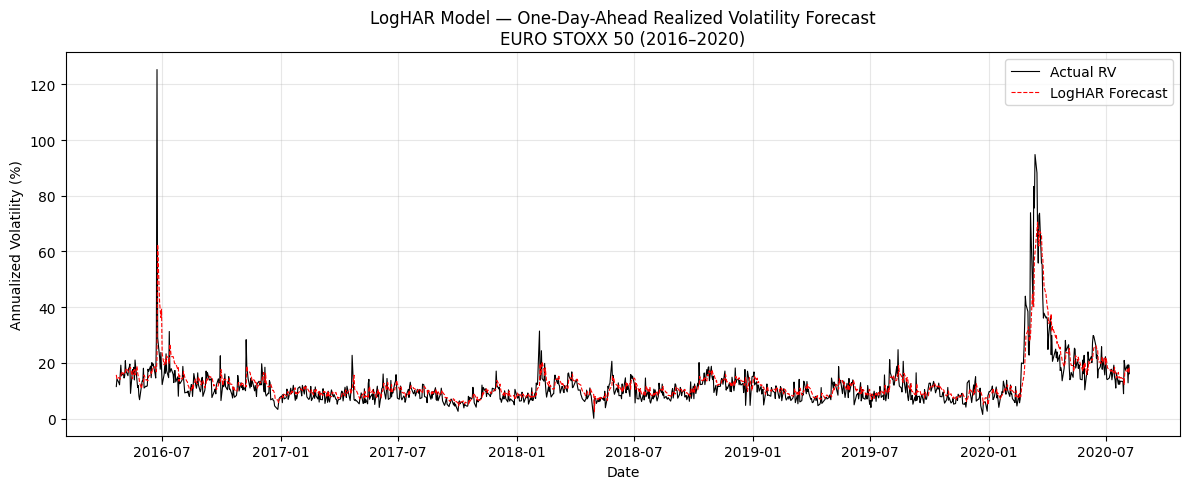


Summary of forecast errors:
Mean error:  3.008511e-06
RMSE:        2.302411e-04
MAE:         4.612122e-05


In [79]:
import matplotlib.pyplot as plt

# Convert to annualized volatility for readability
results_plot = pd.DataFrame({
    "Actual":   np.sqrt(results_LogHAR["RV_actual"] * 252) * 100,
    "Forecast": np.sqrt(results_LogHAR["RV_forecast"] * 252) * 100
}, index=results_LogHAR.index)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(results_plot["Actual"],   label="Actual RV",        color="black", linewidth=0.8)
ax.plot(results_plot["Forecast"], label="LogHAR Forecast",  color="red",   linewidth=0.8, linestyle="--")

ax.set_title("LogHAR Model — One-Day-Ahead Realized Volatility Forecast\nEURO STOXX 50 (2016–2020)", fontsize=12)
ax.set_ylabel("Annualized Volatility (%)")
ax.set_xlabel("Date")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# -------------------
# Error metrics
# -------------------
print(f"\nSummary of forecast errors:")
errors = results_LogHAR["RV_actual"] - results_LogHAR["RV_forecast"]

print(f"Mean error:  {errors.mean():.6e}")
print(f"RMSE:        {np.sqrt(mse_LogHAR):.6e}")
print(f"MAE:         {errors.abs().mean():.6e}")